# Lab : Image Classification using Convolutional Neural Networks

At the end of this laboratory, you would get familiarized with

*   Creating deep networks using Keras
*   Steps necessary in training a neural network
*   Prediction and performance analysis using neural networks

---

# **In case you use a colaboratory environment**
By default, Colab notebooks run on CPU.
You can switch your notebook to run with GPU.

In order to obtain access to the GPU, you need to choose the tab Runtime and then select “Change runtime type” as shown in the following figure:

![Changing runtime](https://miro.medium.com/max/747/1*euE7nGZ0uJQcgvkpgvkoQg.png)

When a pop-up window appears select GPU. Ensure “Hardware accelerator” is set to GPU.

# **Working with a new dataset: CIFAR-10**

The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images. More information about CIFAR-10 can be found [here](https://www.cs.toronto.edu/~kriz/cifar.html).

In Keras, the CIFAR-10 dataset is also preloaded in the form of four Numpy arrays. x_train and y_train contain the training set, while x_test and y_test contain the test data. The images are encoded as Numpy arrays and their corresponding labels ranging from 0 to 9.

Your task is to:

*   Visualize the images in CIFAR-10 dataset. Create a 10 x 10 plot showing 10 random samples from each class.
*   Convert the labels to one-hot encoded form.
*   Normalize the images.




In [11]:
import tarfile
import pickle
import numpy as np

def load_batch(tar, name):
    file = tar.extractfile('cifar-10-batches-py/' + name)
    batch = pickle.load(file, encoding='bytes')
    images = batch[b'data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    labels = np.array(batch[b'labels'])
    return images, labels

with tarfile.open('/content/cifar-10-python.tar.gz') as tar:
    batches = [load_batch(tar, f'data_batch_{i}') for i in range(1, 6)]
    x_test, y_test = load_batch(tar, 'test_batch')

x_train = np.concatenate([batch[0] for batch in batches])
y_train = np.concatenate([batch[1] for batch in batches])

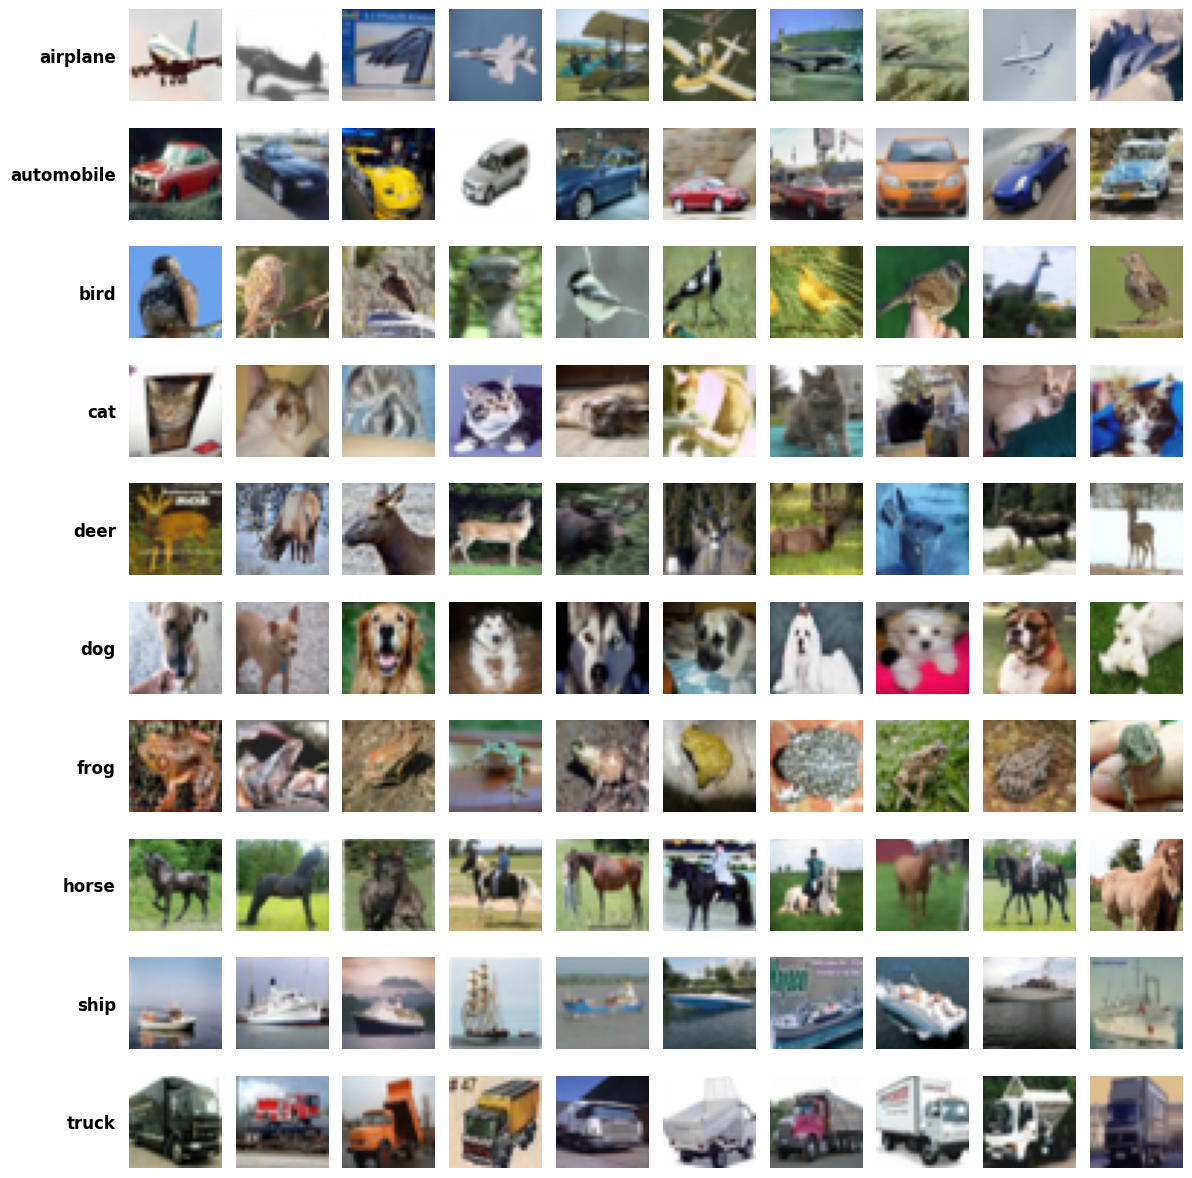

In [12]:
import random

# 1. Define the human-readable class names for CIFAR-10
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# 2. Set up a 10x10 matplotlib figure grid
fig, axes = plt.subplots(10, 10, figsize=(12, 12))

# 3. Flatten the labels array to make indexing easy
y_train_flat = y_train.flatten()

# 4. Loop through each of the 10 classes
for class_idx in range(10):
    # Find all indices in the training set belonging to the current class
    indices = np.where(y_train_flat == class_idx)[0]

    # Pick 10 random indices from those matches
    random_indices = random.sample(list(indices), 10)

    for sample_idx in range(10):
        # Select the target subplot axis
        ax = axes[class_idx, sample_idx]

        # Get the actual image data
        img_idx = random_indices[sample_idx]
        ax.imshow(x_train[img_idx])

        # Turn off grid axis lines and numbers
        ax.axis('off')

        # Label the first image in each row with its class name
        if sample_idx == 0:
            ax.text(-5, 16, class_names[class_idx],
                    ha='right', va='center', fontsize=12, weight='bold')

plt.tight_layout()
plt.show()


In [15]:
# 1. Convert training and testing labels to one-hot encoded vectors
y_train_encoded = to_categorical(y_train, num_classes=10)
y_test_encoded = to_categorical(y_test, num_classes=10)

# 2. Verify the conversion by printing shapes and a quick example
print("Original label format (Integer):")
print(f"y_train shape: {y_train.shape}")
#print(f"First label value: {y_train[0][0]}")

print("\nNew label format (One-Hot Encoded):")
print(f"y_train_encoded shape: {y_train_encoded.shape}")
print(f"First label vector: {y_train_encoded[0]}")


Original label format (Integer):
y_train shape: (50000,)

New label format (One-Hot Encoded):
y_train_encoded shape: (50000, 10)
First label vector: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


In [16]:
# 1. Convert pixel values to float32 and scale them to a range of [0, 1]
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

# 2. Verify the normalization results
print("Before Normalization:")
print(f"Original Data Type: {x_train.dtype}")
print(f"Original Pixel Range: {x_train.min()} to {x_train.max()}")

print("\nAfter Normalization:")
print(f"Normalized Data Type: {x_train_norm.dtype}")
print(f"Normalized Pixel Range: {x_train_norm.min()} to {x_train_norm.max()}")


Before Normalization:
Original Data Type: uint8
Original Pixel Range: 0 to 255

After Normalization:
Normalized Data Type: float32
Normalized Pixel Range: 0.0 to 1.0


## Define the following model (same as the one in tutorial)

For the convolutional front-end, start with a single convolutional layer with a small filter size (3,3) and a modest number of filters (32) followed by a max pooling layer.

Use the input as (32,32,3).

The filter maps can then be flattened to provide features to the classifier.

Use a dense layer with 100 units before the classification layer (which is also a dense layer with softmax activation).

In [17]:
from keras.backend import clear_session
clear_session()

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# 1. Initialize the sequential model
model = Sequential()

# 2. Add the convolutional front-end layer
# 32 filters, (3,3) kernel size, ReLU activation, and matching input image shape
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))

# 3. Add the max pooling layer (defaults to a 2x2 pool size)
model.add(MaxPooling2D((2, 2)))

# 4. Flatten the 2D filter maps into a 1D vector for the dense classifier
model.add(Flatten())

# 5. Add the hidden dense layer with 100 hidden units
model.add(Dense(100, activation='relu'))

# 6. Add the final output classification layer with 10 units (one for each class)
model.add(Dense(10, activation='softmax'))

# 7. Print the model structural summary to verify layer configurations
model.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       720,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 722,006 (2.75 MB)

 Trainable params: 722,006 (2.75 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [19]:
from tensorflow.keras.optimizers import SGD

# 1. Compile the model with SGD optimizer, categorical crossentropy, and accuracy metric
model.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("⚡ Model compiled successfully. Starting training...\n")

# 2. Train the model using the normalized image data and one-hot encoded labels
history = model.fit(
    x_train_norm,          # Normalized training images
    y_train_encoded,       # One-hot encoded training labels
    epochs=50,             # Number of complete passes over the dataset
    batch_size=512,        # Number of samples processed before updating gradients
    validation_data=(x_test_norm, y_test_encoded), # Track performance on test data
    verbose=1              # Shows a progress bar for each epoch
)


⚡ Model compiled successfully. Starting training...

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.2028 - loss: 2.2197 - val_accuracy: 0.2621 - val_loss: 2.1387
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2755 - loss: 2.0751 - val_accuracy: 0.3043 - val_loss: 2.0192
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3066 - loss: 1.9809 - val_accuracy: 0.2931 - val_loss: 1.9631
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3273 - loss: 1.9268 - val_accuracy: 0.3219 - val_loss: 1.9200
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.3434 - loss: 1.8894 - val_accuracy: 0.3414 - val_loss: 1.8781
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.3529 - loss: 1.8602 - val_accuracy: 0.3496 - val_loss: 1.8516
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3630 - loss: 1.8351 - val_accuracy: 0.3614 - val_loss: 1.8313
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accur

*   Plot the cross entropy loss curve and the accuracy curve

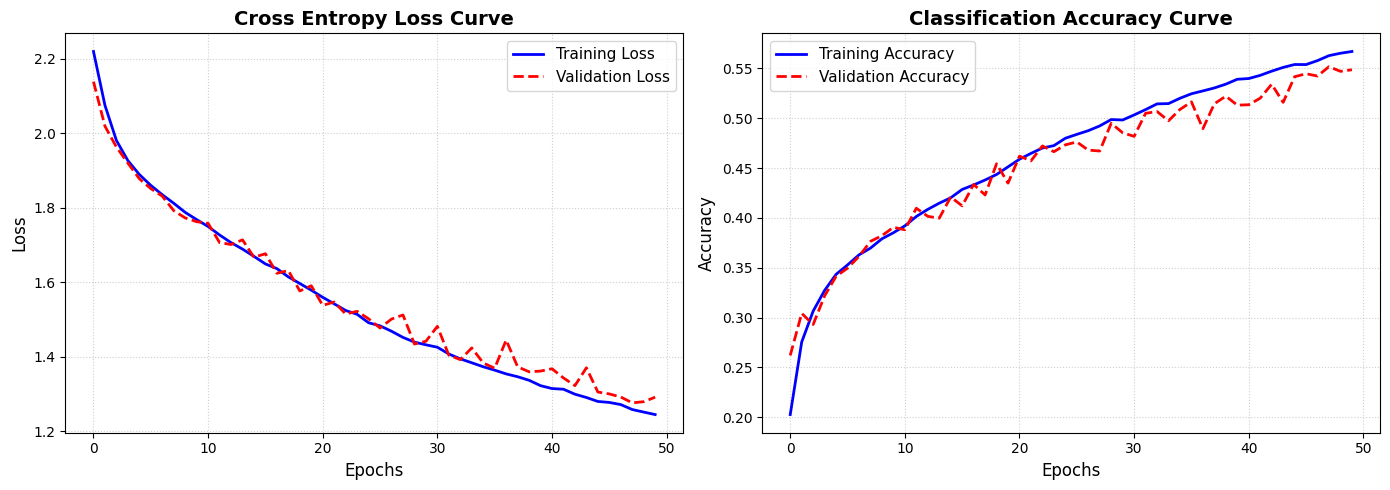

In [20]:
import matplotlib.pyplot as plt

# 1. Create a figure container with two subplots side-by-side
plt.figure(figsize=(14, 5))

# --- Plot 1: Cross Entropy Loss ---
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='red', linestyle='--', linewidth=2)
plt.title('Cross Entropy Loss Curve', fontsize=14, weight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)

# --- Plot 2: Classification Accuracy ---
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', linestyle='--', linewidth=2)
plt.title('Classification Accuracy Curve', fontsize=14, weight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)

# 2. Adjust layouts and render the curves
plt.tight_layout()
plt.show()


## Defining Deeper Architectures: VGG Models

*   Define a deeper model architecture for CIFAR-10 dataset and train the new model for 50 epochs with a batch size of 512. We will use VGG model as the architecture.

Stack two convolutional layers with 32 filters, each of 3 x 3.

Use a max pooling layer and next flatten the output of the previous layer and add a dense layer with 128 units before the classification layer.

For all the layers, use ReLU activation function.

Use same padding for the layers to ensure that the height and width of each layer output matches the input


In [21]:
from keras.backend import clear_session
clear_session()

In [23]:
# 1. Initialize the Sequential model
deeper_model = Sequential()

# 2. First Convolutional layer (32 filters, 3x3 kernel, SAME padding)
deeper_model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))

# 3. Second Convolutional layer stacked right after (32 filters, 3x3 kernel, SAME padding)
deeper_model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))

# 4. Max Pooling layer
deeper_model.add(MaxPooling2D((2, 2)))

# 5. Flatten layer to transition from 2D feature maps to a 1D vector
deeper_model.add(Flatten())

# 6. Dense hidden layer with 128 hidden units
deeper_model.add(Dense(128, activation='relu'))

# 7. Final Classification output layer (10 classes with Softmax activation)
deeper_model.add(Dense(10, activation='softmax'))

# 8. Print the architecture summary
deeper_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,060,138 (4.04 MB)

 Trainable params: 1,060,138 (4.04 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [24]:
# 9. Compile the deeper model using the same parameters as before
deeper_model.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n⚡ Deeper model compiled successfully. Starting 50 epochs of training...\n")

# 10. Train the deeper model
history_deeper = deeper_model.fit(
    x_train_norm,
    y_train_encoded,
    epochs=50,
    batch_size=512,
    validation_data=(x_test_norm, y_test_encoded),
    verbose=1
)


⚡ Deeper model compiled successfully. Starting 50 epochs of training...

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - accuracy: 0.1818 - loss: 2.2427 - val_accuracy: 0.2292 - val_loss: 2.1673
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.2527 - loss: 2.0972 - val_accuracy: 0.2905 - val_loss: 2.0305
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.2966 - loss: 1.9956 - val_accuracy: 0.2834 - val_loss: 2.0334
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.3342 - loss: 1.9171 - val_accuracy: 0.3227 - val_loss: 1.9535
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.3569 - loss: 1.8552 - val_accuracy: 0.3648 - val_loss: 1.8112
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.3714 - loss: 1.8066 - val_accuracy: 0.3650 - val_loss: 1.7840
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.3835 - loss: 1.7722 - val_accuracy: 0.4002 - val_loss: 1.7342
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━

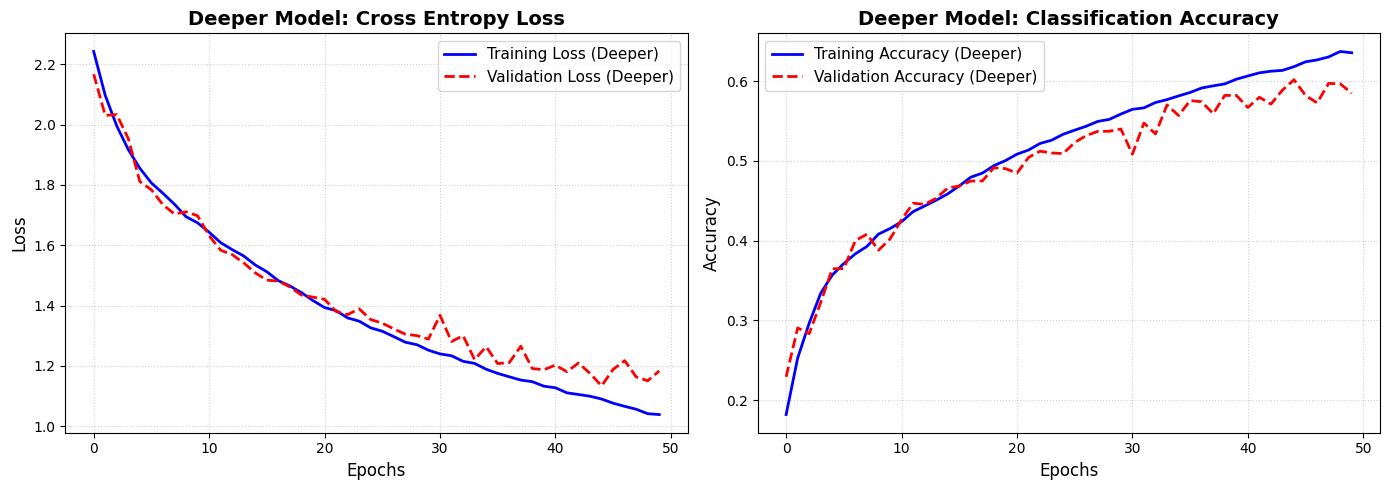

In [25]:
import matplotlib.pyplot as plt

# 1. Create a figure container with two subplots side-by-side
plt.figure(figsize=(14, 5))

# --- Plot 1: Cross Entropy Loss ---
plt.subplot(1, 2, 1)
plt.plot(history_deeper.history['loss'], label='Training Loss (Deeper)', color='blue', linewidth=2)
plt.plot(history_deeper.history['val_loss'], label='Validation Loss (Deeper)', color='red', linestyle='--', linewidth=2)
plt.title('Deeper Model: Cross Entropy Loss', fontsize=14, weight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)

# --- Plot 2: Classification Accuracy ---
plt.subplot(1, 2, 2)
plt.plot(history_deeper.history['accuracy'], label='Training Accuracy (Deeper)', color='blue', linewidth=2)
plt.plot(history_deeper.history['val_accuracy'], label='Validation Accuracy (Deeper)', color='red', linestyle='--', linewidth=2)
plt.title('Deeper Model: Classification Accuracy', fontsize=14, weight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)

# 2. Render the charts
plt.tight_layout()
plt.show()


*   Compare the performance of both the models by plotting the loss and accuracy curves of both the training steps. Does the deeper model perform better? Comment on the observation.


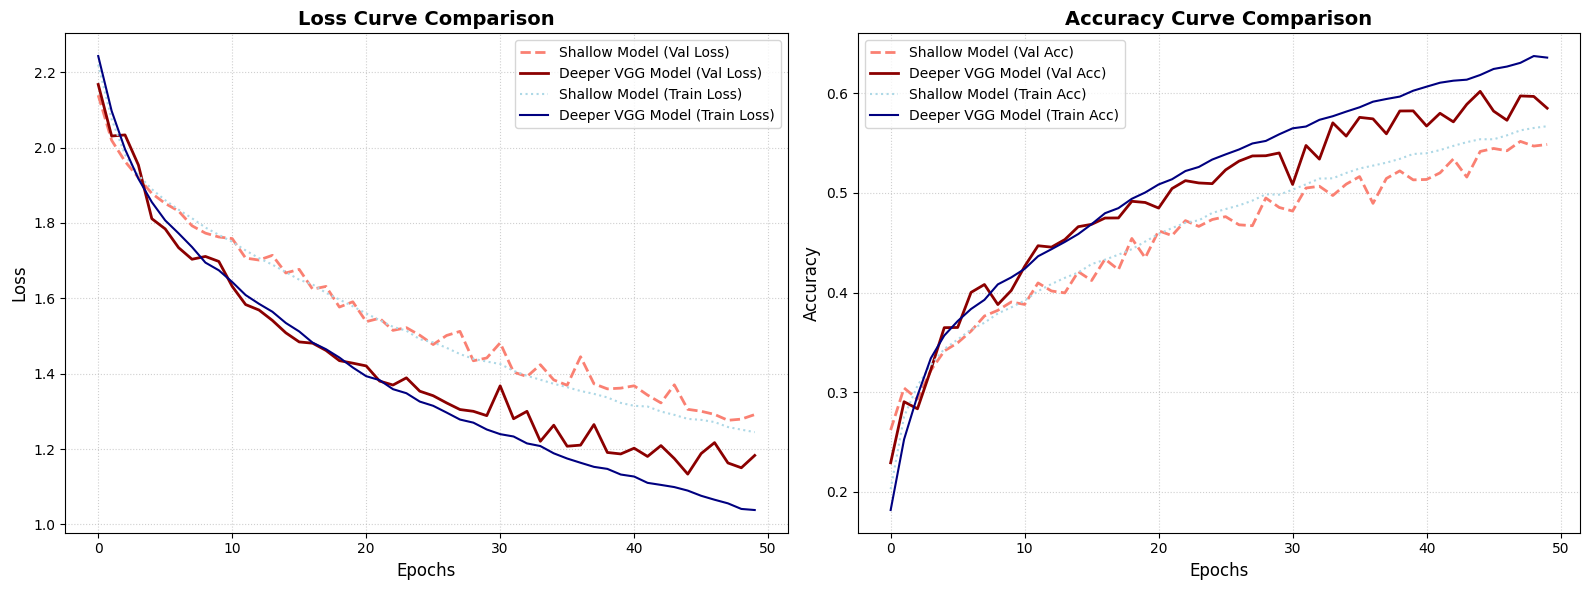

In [26]:
import matplotlib.pyplot as plt

# 1. Initialize a figure with two subplots side-by-side
plt.figure(figsize=(16, 6))

# --- Plot 1: Loss Curve Comparison ---
plt.subplot(1, 2, 1)
plt.plot(history.history['val_loss'], label='Shallow Model (Val Loss)', color='salmon', linestyle='--', linewidth=2)
plt.plot(history_deeper.history['val_loss'], label='Deeper VGG Model (Val Loss)', color='darkred', linewidth=2)
plt.plot(history.history['loss'], label='Shallow Model (Train Loss)', color='lightblue', linestyle=':', linewidth=1.5)
plt.plot(history_deeper.history['loss'], label='Deeper VGG Model (Train Loss)', color='navy', linewidth=1.5)

plt.title('Loss Curve Comparison', fontsize=14, weight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=10)

# --- Plot 2: Accuracy Curve Comparison ---
plt.subplot(1, 2, 2)
plt.plot(history.history['val_accuracy'], label='Shallow Model (Val Acc)', color='salmon', linestyle='--', linewidth=2)
plt.plot(history_deeper.history['val_accuracy'], label='Deeper VGG Model (Val Acc)', color='darkred', linewidth=2)
plt.plot(history.history['accuracy'], label='Shallow Model (Train Acc)', color='lightblue', linestyle=':', linewidth=1.5)
plt.plot(history_deeper.history['accuracy'], label='Deeper VGG Model (Train Acc)', color='navy', linewidth=1.5)

plt.title('Accuracy Curve Comparison', fontsize=14, weight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()


**Comment on the observation**

*The Deeper VGG Model is superior because stacking multiple convolutional layers allows the network to learn complex, hierarchical visual features (like animal features or vehicle edges) required for the CIFAR-10 dataset. Additionally, using padding='same' prevented the feature maps from losing valuable edge pixel information during the early processing stages.
*

...

*   Use predict function to predict the output for the test split
*   Plot the confusion matrix for the new model and comment on the class confusions.


In [28]:
# 1. Generate predictions for the test split images
print("Generating predictions for the test split...")
predictions = deeper_model.predict(x_test_norm, batch_size=512)

# 2. Convert class probabilities back into integer class labels
y_pred_classes = np.argmax(predictions, axis=1)
y_true_classes = np.argmax(y_test_encoded, axis=1)


Generating predictions for the test split...
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


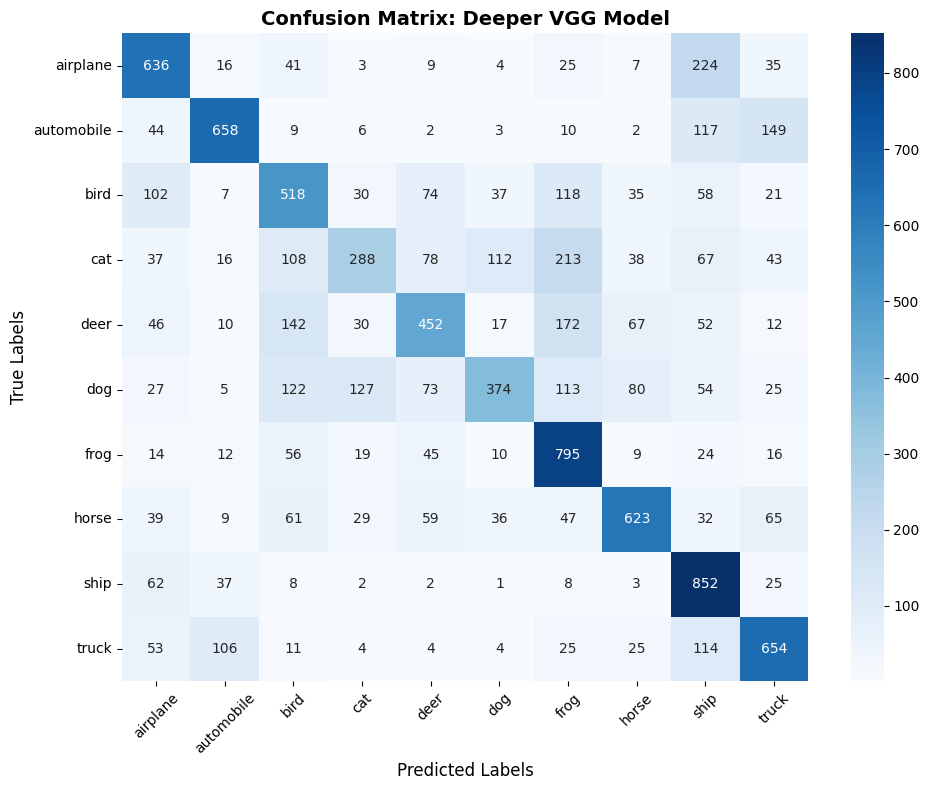

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 3. Define human-readable labels for CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# 4. Generate the confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# 5. Plot the matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: Deeper VGG Model', fontsize=14, weight='bold')
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Comment here :**

* Best Perfomeing : ship (852 correct classifications) and frog (795 correct classifications) *
*Worst Performing : cat (Only 288 correct classifications)*
*The model is excellent at differentiating Vehicles from Animals*

...

*    Print the test accuracy for the trained model.

In [38]:
# Calculate total correct predictions (the sum of the diagonal)
total_correct = np.trace(cm)
total_samples = np.sum(cm)

# Compute the accuracy percentage
final_accuracy = (total_correct / total_samples) * 100

print("=========================================")
print(f"Total Correct Images: {total_correct} / {total_samples}")
print(f"Final Test Accuracy: {final_accuracy:.2f}%")
print("=========================================")


Total Correct Images: 5850 / 10000
Final Test Accuracy: 58.50%


## Define the complete VGG architecture.

Stack two convolutional layers with 64 filters, each of 3 x 3 followed by max pooling layer.

Stack two more convolutional layers with 128 filters, each of 3 x 3, followed by max pooling, followed by two more convolutional layers with 256 filters, each of 3 x 3, followed by max pooling.

Flatten the output of the previous layer and add a dense layer with 128 units before the classification layer.

For all the layers, use ReLU activation function.

Use same padding for the layers to ensure that the height and width of each layer output matches the input

*   Change the size of input to 64 x 64.

In [32]:
from keras.backend import clear_session
clear_session()

In [33]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Resizing

# 1. Initialize sequential model with a resizing layer to scale images to 64x64
vgg_complete = Sequential([
    Resizing(64, 64, input_shape=(32, 32, 3)),

    # Block 1: 2x Conv (64 filters) + MaxPool
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    # Block 2: 2x Conv (128 filters) + MaxPool
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    # Block 3: 2x Conv (256 filters) + MaxPool
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    # Classifier Head
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

vgg_complete.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,243,978 (12.37 MB)

 Trainable params: 3,243,978 (12.37 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 10 epochs with a batch size of 512.
*   Predict the output for the test split and plot the confusion matrix for the new model and comment on the class confusions.

In [48]:
from tensorflow.keras.optimizers import SGD
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. Compile the new VGG model
vgg_complete.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
# Option A: Switch to Adam (Highly Recommended for Deep VGG)
#model.compile(
#    optimizer='adam',
#    loss='categorical_crossentropy',
#    metrics=['accuracy'])


print("Model compiled. ")

Model compiled. 


In [49]:

print("Training complete VGG model for 10 epochs on 64x64 inputs...\n")
# 2. Train the model using the normalized training image data split
history_vgg = vgg_complete.fit(
    x_train_norm,
    y_train_encoded,
    epochs=10,
    batch_size=512,
    validation_data=(x_test_norm, y_test_encoded),
    verbose=1
)


Training complete VGG model for 10 epochs on 64x64 inputs...

Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 46s 442ms/step - accuracy: 0.5407 - loss: 1.3072 - val_accuracy: 0.5322 - val_loss: 1.3296
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 38s 393ms/step - accuracy: 0.5490 - loss: 1.2829 - val_accuracy: 0.5181 - val_loss: 1.3464
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 39s 401ms/step - accuracy: 0.5567 - loss: 1.2625 - val_accuracy: 0.5547 - val_loss: 1.2692
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 39s 397ms/step - accuracy: 0.5658 - loss: 1.2352 - val_accuracy: 0.5467 - val_loss: 1.2770
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 39s 399ms/step - accuracy: 0.5694 - loss: 1.2279 - val_accuracy: 0.5454 - val_loss: 1.2943
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 39s 398ms/step - accuracy: 0.5840 - loss: 1.1923 - val_accuracy: 0.5295 - val_loss: 1.3186
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 39s 397ms/step - accuracy: 0.5896 - loss: 1.1703 - val_accuracy: 0.5647 - val_loss: 1.2411
Epoch 8/10
98/98 ━━━━━━━━━━━━━━━━━━

In [50]:
# 3. Generate test split predictions
print("\nGenerating predictions for the test split data...")
vgg_predictions = vgg_complete.predict(x_test_norm, batch_size=512)

# 4. Extract target class integer maps
y_pred_vgg = np.argmax(vgg_predictions, axis=1)
y_true_vgg = np.argmax(y_test_encoded, axis=1)
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']



Generating predictions for the test split data...
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 138ms/step


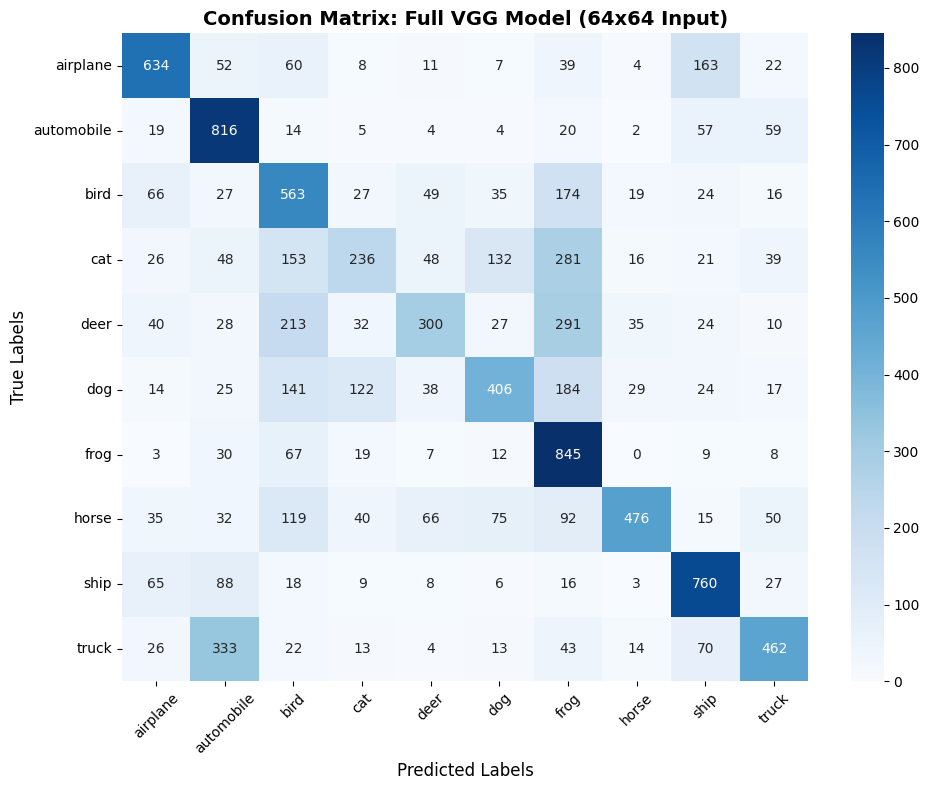

In [51]:
# 5. Compute and plot the Confusion Matrix
cm_vgg = confusion_matrix(y_true_vgg, y_pred_vgg)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_vgg, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: Full VGG Model (64x64 Input)', fontsize=14, weight='bold')
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Understanding deep networks

*   What is the use of activation functions in network? Why is it needed?
*   We have used softmax activation function in the exercise. There are other activation functions available too. What is the difference between sigmoid activation and softmax activation?
*   What is the difference between categorical crossentropy and binary crossentropy loss?

**Write the answers below :**

**1 - Use of activation functions:**
  a)It Allows the Network to Learn Complex, Real-World Data
  b)It Prevents "Network Collapse"
  c)It Controls Neuron Activation (The Gatekeeper)


**2 - Key Differences between sigmoid and softmax:**
   **Sigmoid:**
        a)Processes each output neuron independently from the others.
        b)The outputs do not sum to 1. Each class ranges from 0 to 1   independently.
        c)Binary (Is this a cat or not?) or Multi-label (Can contain a cat and a tree simultaneously).
**Softmax:**
        a)Processes all output neurons interdependently as a group.
        b)The sum of all outputs is exactly 1.0 (100%).
        c)Multi-class (Is this a cat, a dog, or a truck? It can only be one).

**3 - Key Differences between categorical crossentropy and binary crossentropy loss:**
 **categorical crossentropy :**
        a)is used when an item can only belong to one exclusive category out of many options
        b)Pair this loss function with Softmax
  **Binary Cross-Entropy  :**
        a)is used for Yes/No choices or when an item can have multiple labels at the same time.
        b)Pair this loss function with Sigmoid.

